In [1]:
import arviz.preview as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

In [2]:
NUM_OBS = [50, 250, 500, 1000]

In [3]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           24,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      24,
    "legend.fontsize":     20,
    "xtick.labelsize":     20,
    "ytick.labelsize":     20,
})

sns.set_theme(context="paper", style="ticks", font_scale=1.5)

In [4]:
RHAT_THRESHOLD = 1.05


def mask_bad_subjects(dt, threshold=RHAT_THRESHOLD):
    param_names = list(dt.param_names)
    rhat_ds = az.rhat(dt["posterior"].ds[param_names])
    valid = (rhat_ds.to_array(dim="param") < threshold).all(dim="param")

    print("Converged subjects: ", valid.sum().item(), valid.mean().item())

    new_dt = xr.DataTree.from_dict({
        "posterior": dt["posterior"].ds.where(valid),
        "constant_data": dt["constant_data"].ds.where(valid),
        "prior": dt["prior"].ds,
    })
    new_dt.attrs = dt.attrs
    return new_dt

## RDM

In [5]:
dt_dict_rdm_approx = {}

for t in NUM_OBS:
    dt_path = f"../multirun/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=500000/parameter_recovery_approx.nc"
    dt_dict_rdm_approx[t] = mask_bad_subjects(open_datatree(dt_path))

Converged subjects:  100 1.0
Converged subjects:  100 1.0
Converged subjects:  100 1.0
Converged subjects:  99 0.99


In [6]:
dt_dict_rdm_ref = {}

for t in NUM_OBS:
    dt_path = f"../multirun/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=500000/parameter_recovery_ref.nc"
    dt_dict_rdm_ref[t] = mask_bad_subjects(open_datatree(dt_path))

Converged subjects:  100 1.0
Converged subjects:  100 1.0
Converged subjects:  100 1.0
Converged subjects:  100 1.0


In [7]:
num_obs_coord = xr.DataArray(NUM_OBS, dims="num_obs")   

def merge_datatrees(dt_dict):
    groups = ["posterior", "constant_data", "prior"]                                                                                                                                            
                                                                                                                                                                                            
    dt_merged = xr.DataTree.from_dict({                                                                                                                                                            
        group: xr.concat(                                                                                                                                                                       
            [dt_dict[t][group].ds for t in NUM_OBS],                                                                                                                                            
            dim=num_obs_coord                                                                                                                                                                   
        )                                                                                                                                                                                       
        for group in groups                                                                                                                                                                     
    })

    dt_merged.attrs = dt_dict[50].attrs

    return dt_merged

In [8]:
dt_merged_rdm_approx = merge_datatrees(dt_dict_rdm_approx)
dt_merged_rdm_ref = merge_datatrees(dt_dict_rdm_ref)

In [9]:
def stack_posterior(dt):
    return (dt["posterior"].ds[dt.param_names]                                                                                                                  
    .to_array(dim="param")                                                                                       
    .to_dataset(name="theta")                                                                                                               
    ).merge(dt["constant_data"].ds.rename({"theta": "true"}))

In [10]:
posterior_stacked_rdm_approx = stack_posterior(dt_merged_rdm_approx)
posterior_stacked_rdm_ref = stack_posterior(dt_merged_rdm_ref)

In [11]:
def calc_posterior_median_df(posterior_stacked):
    return (posterior_stacked
        .median(dim=["chain", "draw"])
    ).to_dataframe().reset_index()


def calc_posterior_ci_df(posterior_stacked, q_low=0.025, q_high=0.975):
    quantiles = posterior_stacked.theta.quantile(
        [q_low, 0.5, q_high], dim=["chain", "draw"]
    )
    return (
        xr.Dataset({
            "lower": quantiles.sel(quantile=q_low, drop=True),
            "theta": quantiles.sel(quantile=0.5, drop=True),
            "upper": quantiles.sel(quantile=q_high, drop=True),
        })
        .merge(posterior_stacked.true)
        .to_dataframe()
        .reset_index()
    )


def scatter_with_ci(data, **kwargs):
    ax = plt.gca()
    yerr = np.vstack([
        data["theta"] - data["lower"],
        data["upper"] - data["theta"],
    ])
    ax.errorbar(
        data["true"], data["theta"],
        yerr=yerr,
        fmt="o", markersize=3,
        elinewidth=0.5, ecolor="gray", alpha=0.6,
        zorder=1,
    )

In [12]:
df_posterior_median_rdm_approx = calc_posterior_median_df(posterior_stacked_rdm_approx)
df_posterior_median_rdm_ref = calc_posterior_median_df(posterior_stacked_rdm_ref)

df_posterior_median_rdm_join = df_posterior_median_rdm_approx.merge(
    df_posterior_median_rdm_ref,
    on=["subject", "num_obs", "param"],
    suffixes=["_approx", "_ref"]
)

df_posterior_ci_rdm_approx = calc_posterior_ci_df(posterior_stacked_rdm_approx)


/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [13]:
def calc_posterior_median_true_correlation(df):
    return (df
        .drop(["subject"], axis=1)
        .groupby(["num_obs", "param"])
        .corr()
        .iloc[0::2,-1]
        .reset_index()
    )

In [14]:
df_cor_rdm_approx = calc_posterior_median_true_correlation(df_posterior_median_rdm_approx)

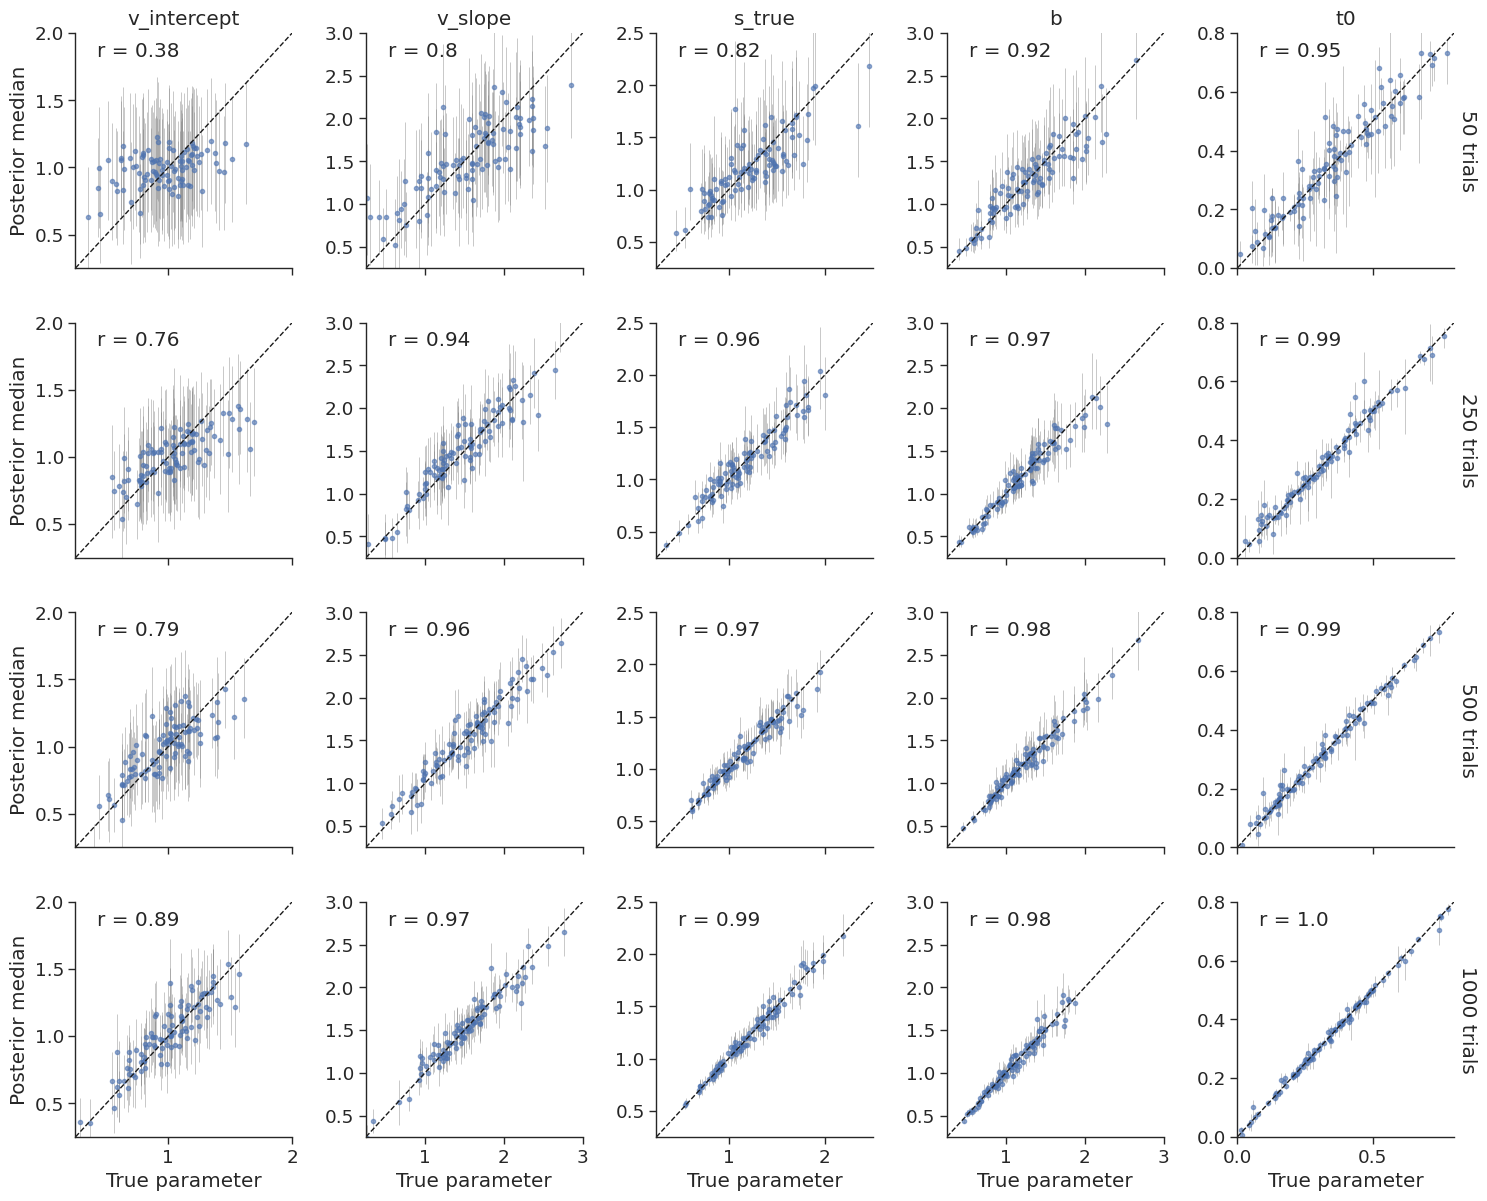

In [15]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

g = sns.FacetGrid(df_posterior_ci_rdm_approx, row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(scatter_with_ci)

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Posterior median")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.5),
    "b": (0.25, 3.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1, zorder=2)
    cor = np.round(df_cor_rdm_approx[(df_cor_rdm_approx["num_obs"] == row_val) & (df_cor_rdm_approx["param"] == col_val)]["true"].item(), 2)
    ax.text(0.1, 0.9, f"r = {cor}", transform=ax.transAxes)

g.savefig("parameter_recovery/parameter_recovery_single_rdm.png")

In [16]:
df_cor_rdm_join = (df_posterior_median_rdm_join
    .drop(["subject"], axis=1)
    .groupby(["num_obs", "param"])
    .corr()
    .iloc[0::4,-2]
    .reset_index()
    .pivot(index="num_obs", columns="param", values="theta_ref")
    .round(4)
)

print(df_cor_rdm_join.to_latex(float_format="%.4f"))

\begin{tabular}{lrrrrr}
\toprule
param & b & s_true & t0 & v_intercept & v_slope \\
num_obs &  &  &  &  &  \\
\midrule
50 & 0.9998 & 0.9995 & 0.9998 & 0.9977 & 0.9996 \\
250 & 0.9998 & 0.9998 & 0.9998 & 0.9981 & 0.9996 \\
500 & 0.9996 & 0.9998 & 0.9998 & 0.9975 & 0.9995 \\
1000 & 0.9997 & 0.9998 & 0.9999 & 0.9988 & 0.9994 \\
\bottomrule
\end{tabular}



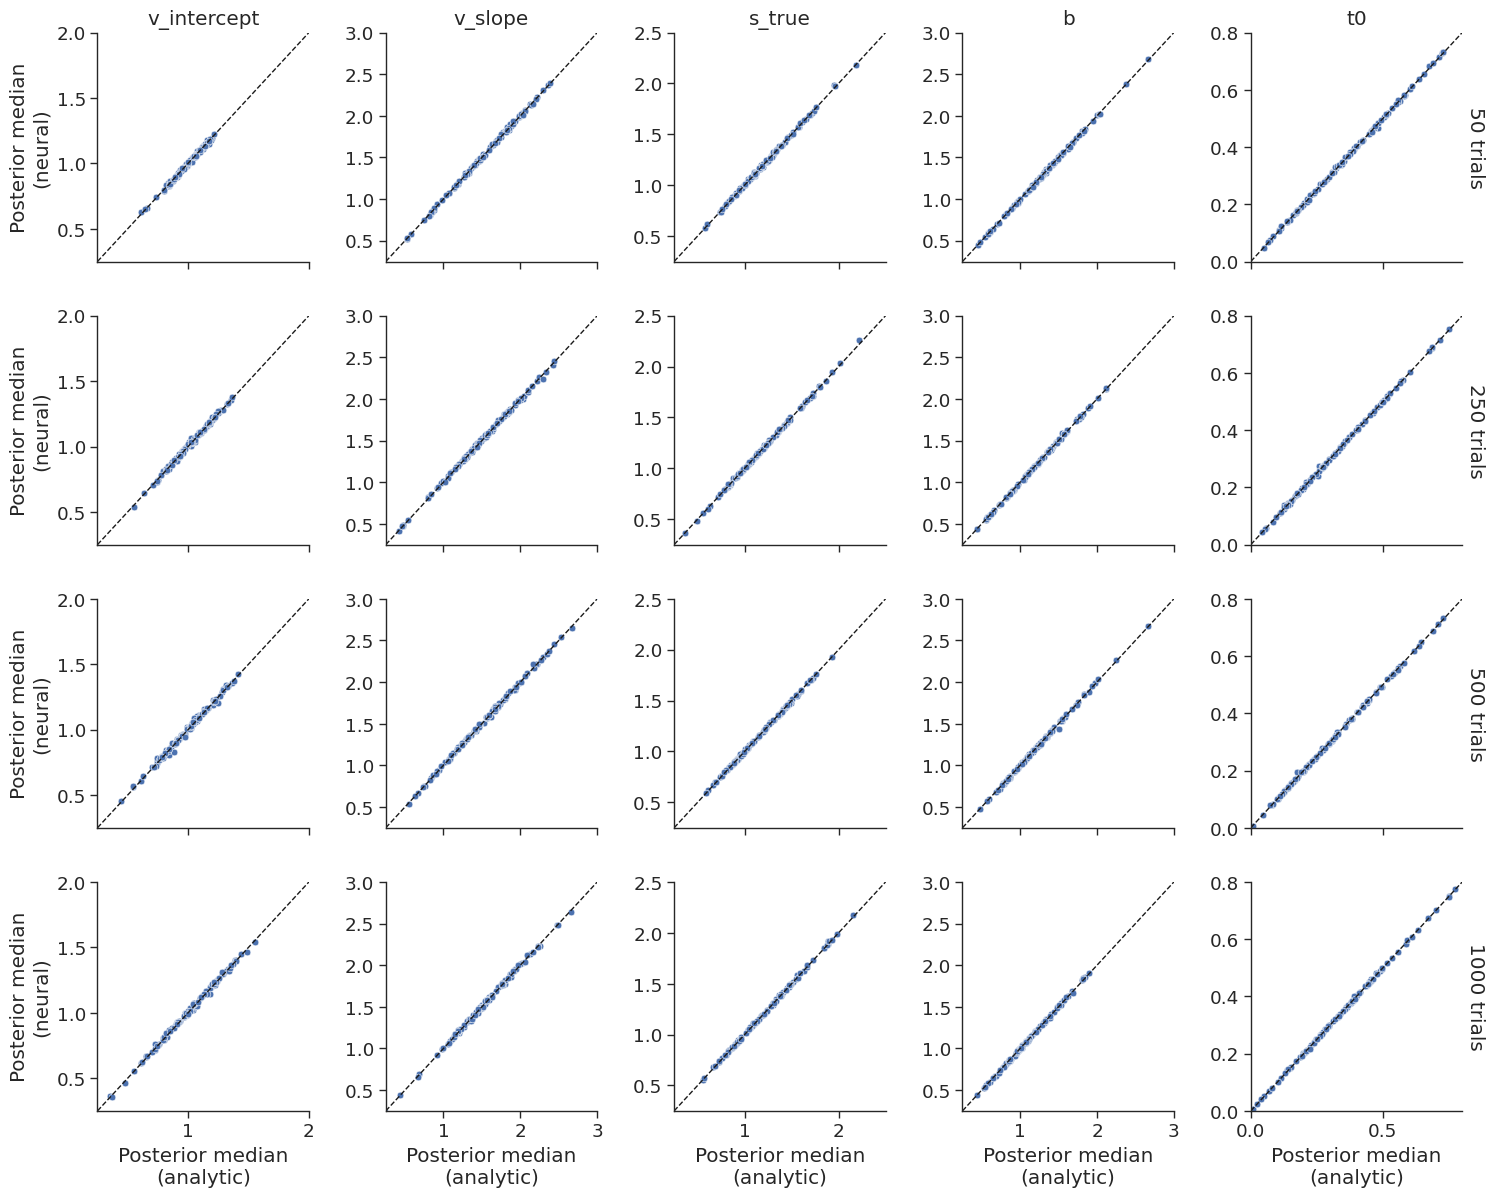

In [17]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

g = sns.FacetGrid(df_posterior_median_rdm_join, row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx")

g.set_xlabels(label="Posterior median\n(analytic)")
g.set_ylabels(label="Posterior median\n(neural)")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.5),
    "b": (0.25, 3.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_single_rdm.png")

In [18]:
def merge_prior(posterior_stacked, dt):
    return posterior_stacked.merge(dt["prior"].ds[dt.param_names].to_array(dim="param").to_dataset(name="prior"))

In [19]:
posterior_prior_stacked_rdm_approx = merge_prior(posterior_stacked_rdm_approx, dt_merged_rdm_approx)
posterior_prior_stacked_rdm_ref = merge_prior(posterior_stacked_rdm_ref, dt_merged_rdm_ref)

In [20]:
def calc_posterior_contraction_df(dt):
    posterior_var = dt.theta.var(dim=["chain", "draw"])
    prior_var = dt.prior.var(dim=["draw"])
    return ((1.0 - (posterior_var / prior_var))
        .to_dataset(name="contraction")
        .merge(dt.mean(dim=["chain", "draw"]))
        .to_dataframe()
        .reset_index()
    )

In [21]:
df_posterior_contraction_rdm_approx = calc_posterior_contraction_df(posterior_prior_stacked_rdm_approx)
df_posterior_contraction_rdm_ref = calc_posterior_contraction_df(posterior_prior_stacked_rdm_ref)

df_posterior_contraction_rdm_join = df_posterior_contraction_rdm_approx.merge(
    df_posterior_contraction_rdm_ref, on=["subject", "num_obs", "param", "true"], suffixes=["_approx", "_ref"]
).melt(
    id_vars=["subject", "num_obs", "param", "true"],
    value_vars=["contraction_approx", "contraction_ref"],
    var_name="method",
)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


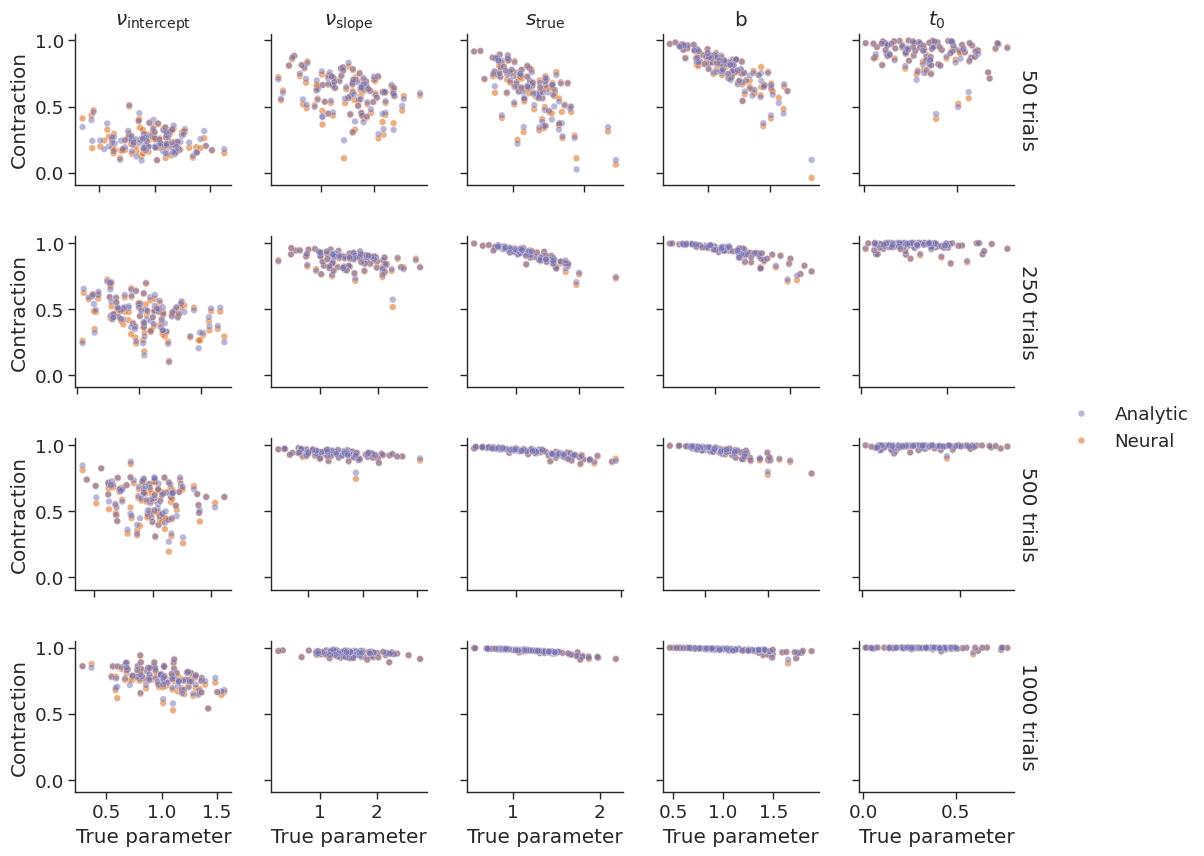

In [22]:
param_labels = {
    "v_intercept": r"$\nu_\text{intercept}$",
    "v_slope": r"$\nu_\text{slope}$",
    "s_true": r"$s_\text{true}$",
    "t0": r"$t_0$",
}

df_posterior_contraction_rdm_join["param"] = df_posterior_contraction_rdm_join["param"].replace(param_labels)

g = sns.FacetGrid(
    df_posterior_contraction_rdm_join,
    row="num_obs",
    col="param",
    # col_order=dt_merged_rdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
    height=2.2,
    
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="value", hue="method", alpha=0.5, palette=["#d95f02", "#7570b3"])

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Contraction")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

g.add_legend({
    "Analytic": g._legend_data["contraction_ref"],
    "Neural": g._legend_data["contraction_approx"],
})

# plt.legend()

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

g.savefig("parameter_recovery/posterior_contraction_single_rdm.png")

In [23]:
def calc_coverage_df(dt):
    lower = dt.quantile(dim=["chain", "draw"], q=0.025)
    upper = dt.quantile(dim=["chain", "draw"], q=0.975)
    true = dt.true
    covered = ((true > lower) & (true < upper)).theta.astype(float)
    covered = covered.where(lower.theta.notnull())
    return (covered
        .mean(dim="subject", skipna=True)
        .to_dataset(name="coverage")
        .to_dataframe()
        .reset_index()
    )

df_coverage_rdm_approx = calc_coverage_df(posterior_stacked_rdm_approx)
df_coverage_rdm_ref = calc_coverage_df(posterior_stacked_rdm_ref)

df_coverage_rdm_join = df_coverage_rdm_approx.merge(
    df_coverage_rdm_ref, on=["num_obs", "param"], suffixes=["_approx", "_ref"],
).melt(
    id_vars=["num_obs", "param"],
    value_vars=["coverage_approx", "coverage_ref"],
    var_name="method",
)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


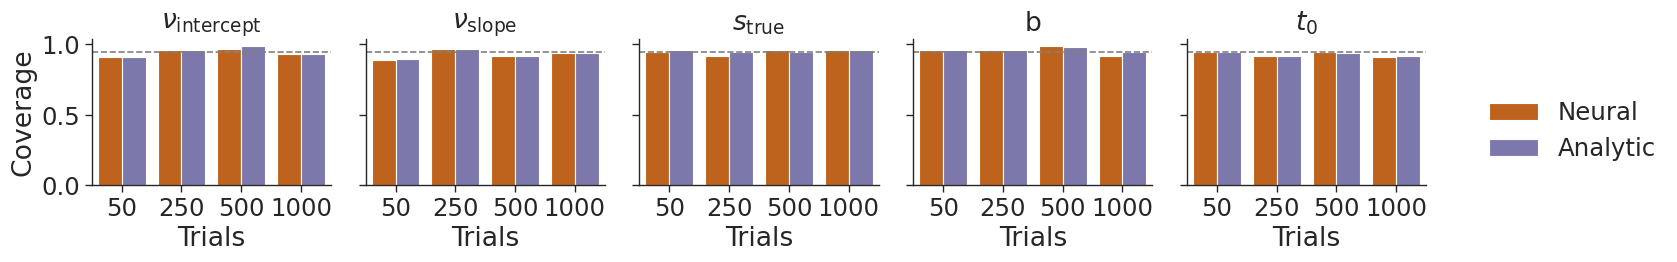

In [24]:
sns.set_theme(context="paper", style="ticks", font_scale=2.0)

df_coverage_rdm_join["param"] = df_coverage_rdm_join["param"].replace(param_labels)

g = sns.FacetGrid(
    df_coverage_rdm_join,
    col="param",
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.barplot, x="num_obs", y="value", hue="method", palette=["#d95f02", "#7570b3"])

g.refline(y=0.95)
g.set(yticks=[0, 0.5, 1.0])

g.set_xlabels(label="Trials")
g.set_ylabels(label="Coverage")

g.set_titles(col_template="{col_name}")

g.add_legend({
    "Neural": g._legend_data["coverage_approx"],
    "Analytic": g._legend_data["coverage_ref"],
})

g.savefig("parameter_recovery/coverage_single_rdm.png")

In [25]:
df_c2st = pd.read_csv("../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/c2st.csv")

/tmp/ipykernel_19589/1165633383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19589/1165633383.py:6: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


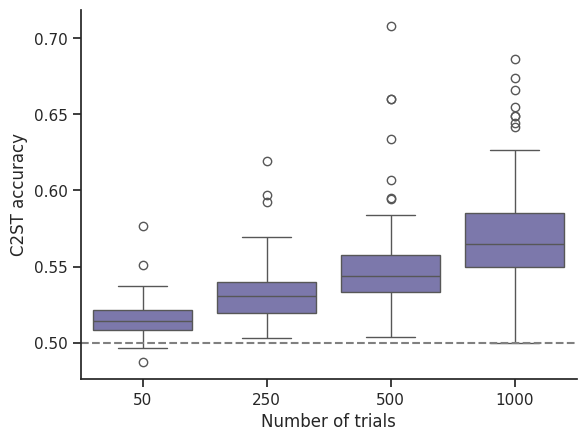

In [26]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

fig, ax = plt.subplots()

sns.boxplot(
    df_c2st,
    x="num_obs", y="c2st_accuracy",
    ax=ax,
    palette=["#7570b3"]
)

ax.hlines(0.5, xmin=-0.5, xmax=3.5, linestyles="--", colors="grey")

ax.set_xlim((-0.5, 3.5))

ax.set_xlabel("Number of trials")
ax.set_ylabel("C2ST accuracy")

fig.savefig("parameter_recovery/c2st_single_rdm.png")

## CRDM

In [27]:
dt_dict_crdm_approx = {}

for t in NUM_OBS:
    dt_path = f"../multirun/crdm/crdm/model.num_bins=12/model.num_mid=128/model.recovery_prior.v_c_slope_loc=2.5/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=1000000/parameter_recovery_approx.nc"
    dt_dict_crdm_approx[t] = mask_bad_subjects(open_datatree(dt_path))

Converged subjects:  95 0.95
Converged subjects:  97 0.97
Converged subjects:  94 0.94
Converged subjects:  94 0.94


In [28]:
dt_merged_crdm_approx = merge_datatrees(dt_dict_crdm_approx)

In [29]:
posterior_stacked_crdm_approx = stack_posterior(dt_merged_crdm_approx)

In [30]:
df_posterior_median_crdm_approx = calc_posterior_median_df(posterior_stacked_crdm_approx)
df_posterior_ci_crdm_approx = calc_posterior_ci_df(posterior_stacked_crdm_approx)


/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [31]:
df_cor_crdm_approx = calc_posterior_median_true_correlation(df_posterior_median_crdm_approx)

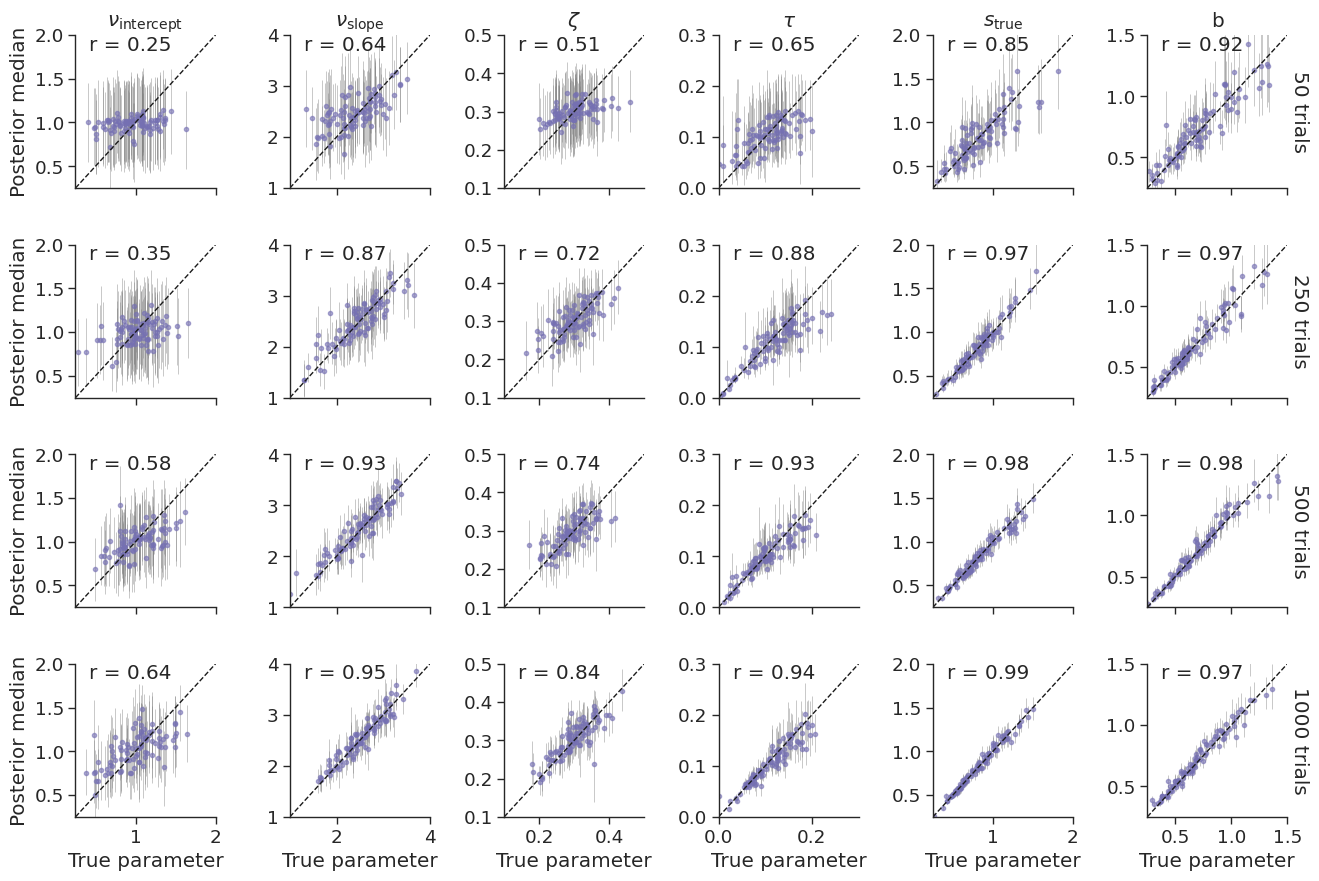

In [32]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)


def scatter_with_ci(data, **kwargs):
    ax = plt.gca()
    yerr = np.vstack([
        data["theta"] - data["lower"],
        data["upper"] - data["theta"],
    ])
    ax.errorbar(
        data["true"], data["theta"],
        yerr=yerr,
        fmt="o", markersize=3, color="#7570b3",
        elinewidth=0.5, ecolor="gray", alpha=0.6,
        zorder=1,
    )

param_labels = {
    "v_c_intercept": r"$\nu_\text{intercept}$",
    "v_c_slope": r"$\nu_\text{slope}$",
    "amp": r"$\zeta$",
    "tau": r"$\tau$",
    "s_true": r"$s_\text{true}$",
    "t0": r"$t_0$",
}

df_posterior_ci_crdm_approx["param"] = df_posterior_ci_crdm_approx["param"].replace(param_labels)

df_cor_crdm_approx["param"] = df_cor_crdm_approx["param"].replace(param_labels)

g = sns.FacetGrid(df_posterior_ci_crdm_approx.loc[df_posterior_ci_crdm_approx["param"] != r"$t_0$", :], row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True, height=2.2)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(scatter_with_ci)

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Posterior median")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    r"$\nu_\text{intercept}$": (0.25, 2.0),
    r"$\nu_\text{slope}$": (1.0, 4.0),
    r"$\zeta$": (0.1, 0.5),
    r"$\tau$": (0, 0.3),
    r"$s_\text{true}$": (0.25, 2.0),
    "b": (0.25, 1.5),
    r"$t_0$": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1, zorder=2)
    cor = np.round(df_cor_crdm_approx[(df_cor_crdm_approx["num_obs"] == row_val) & (df_cor_crdm_approx["param"] == col_val)]["true"].item(), 2)
    ax.text(0.1, 0.9, f"r = {cor}", transform=ax.transAxes)

g.savefig("parameter_recovery/parameter_recovery_single_crdm.png")

In [33]:
posterior_prior_stacked_crdm_approx = merge_prior(posterior_stacked_crdm_approx, dt_merged_crdm_approx)

In [34]:
df_posterior_contraction_crdm_approx = calc_posterior_contraction_df(posterior_prior_stacked_crdm_approx)
df_posterior_contraction_crdm_approx["contraction"] = np.clip(df_posterior_contraction_crdm_approx["contraction"], 0, 1)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


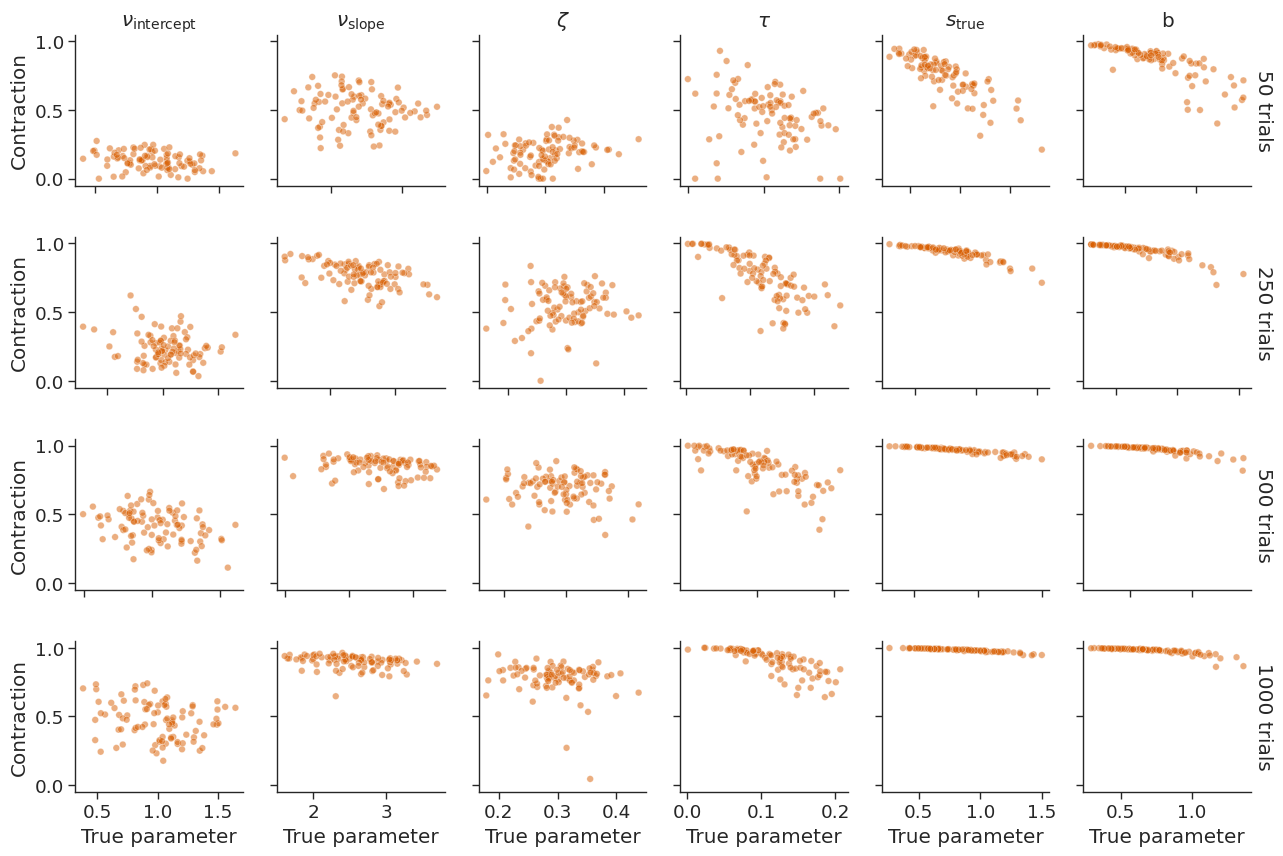

In [35]:
df_posterior_contraction_crdm_approx["param"] = df_posterior_contraction_crdm_approx["param"].replace(param_labels)

g = sns.FacetGrid(
    df_posterior_contraction_crdm_approx.loc[df_posterior_contraction_crdm_approx["param"] != r"$t_0$", :],
    row="num_obs",
    col="param",
    # col_order=dt_merged_crdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
    height=2.2,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="contraction", hue="num_obs", alpha=0.5, palette=["#d95f02"])

g.set_xlabels(label="True parameter")
g.set_ylabels(label="Contraction")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

g.savefig("parameter_recovery/posterior_contraction_single_crdm.png")

In [36]:
df_coverage_crdm_approx = calc_coverage_df(posterior_stacked_crdm_approx)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: 
The palette list has fewer values (1) than needed (4) and w

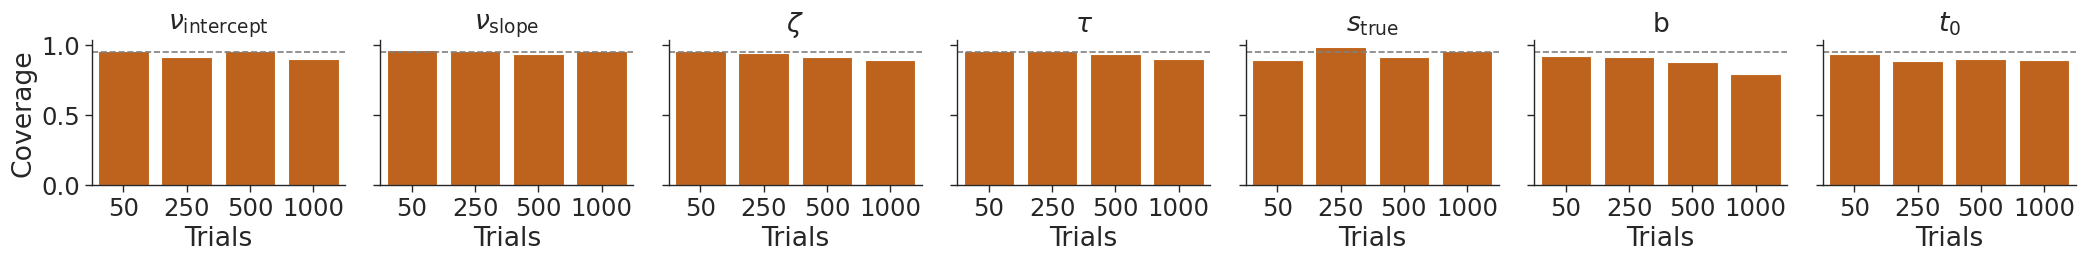

In [37]:
sns.set_theme(context="paper", style="ticks", font_scale=2.0)

df_coverage_crdm_approx["param"] = df_coverage_crdm_approx["param"].replace(param_labels)

g = sns.FacetGrid(
    df_coverage_crdm_approx,
    col="param",
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.barplot, x="num_obs", y="coverage", hue="num_obs", palette=["#d95f02"])

g.refline(y=0.95)

g.set(yticks=[0, 0.5, 1.0])

g.set_xlabels(label="Trials")
g.set_ylabels(label="Coverage")

g.set_titles(col_template="{col_name}")

g.savefig("parameter_recovery/coverage_single_crdm.png")